In [95]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
df = pd.read_csv('diabetes_risk_prediction_dataset.csv')
df

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,...,Yes,Average,Retired,Urban,3.5,86,Consult Endocrinologist Immediately,Yes,High,Obese
49996,49997,53.0,Male,United Kingdom,179.6,64.0,19.8,114.5,198.4,6.3,...,No,Average,Government,Urban,3.4,49,Weight Management Program,No,Moderate,Normal
49997,49998,88.0,Male,Brazil,194.1,65.6,17.4,96.1,118.8,NaN,...,Yes,Poor,Retired,Urban,2.6,100,Begin Diabetes Management Plan,Yes,High,Underweight
49998,49999,23.0,Other,Bangladesh,168.0,73.9,26.2,131.4,139.5,9.2,...,Yes,Good,Private,Urban,2.7,52,Increase Physical Activity,No,Moderate,Overweight


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  str    
 3   Country                     50000 non-null  str    
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    50000 non-null

In [98]:
df.isnull().sum()

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

In [99]:
df.drop('Weight_kg',axis=1,inplace=True)



In [100]:
df.drop('Height_cm',axis=1,inplace=True)


In [101]:
df.drop('Patient_ID',axis=1,inplace= True)

In [102]:
df

,Age,Gender,Country,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,32.0,Male,Mexico,19.8,71.2,88.4,10.4,149.5,27.4,94,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,42.0,Other,Saudi Arabia,45.9,121.8,247.3,11.3,199.3,18.3,148,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,89.0,Other,Argentina,37.9,131.8,141.9,6.3,219.6,23.9,101,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,87.0,Other,United States,26.3,99.1,90.1,7.4,217.7,36.7,120,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,27.0,Other,Australia,41.4,77.1,93.8,12.0,153.5,22.3,190,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,52.0,Female,United Kingdom,45.3,75.9,248.8,9.9,191.5,15.4,97,...,Yes,Average,Retired,Urban,3.5,86,Consult Endocrinologist Immediately,Yes,High,Obese
49996,53.0,Male,United Kingdom,19.8,114.5,198.4,6.3,110.0,13.3,121,...,No,Average,Government,Urban,3.4,49,Weight Management Program,No,Moderate,Normal
49997,88.0,Male,Brazil,17.4,96.1,118.8,NaN,208.4,30.5,176,...,Yes,Poor,Retired,Urban,2.6,100,Begin Diabetes Management Plan,Yes,High,Underweight
49998,23.0,Other,Bangladesh,26.2,131.4,139.5,9.2,84.7,14.8,141,...,Yes,Good,Private,Urban,2.7,52,Increase Physical Activity,No,Moderate,Overweight


In [103]:
df.shape

(50000, 39)

In [104]:
df.columns

Index(['Age', 'Gender', 'Country', 'BMI', 'Waist_Circumference_cm',
       'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate',
       'Physical_Activity_Level', 'Exercise_Hours_Per_Week',
       'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level',
       'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption',
       'Family_History_Diabetes', 'Hypertension', 'Heart_Disease',
       'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type',
       'Residence_Type', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score',
       'AI_Health_Recommendation', 'Doctor_Consultation_Needed',
       'Diabetes_Risk', 'BMI_CATEGORY'],
      dtype='str')

In [105]:
df['Country'].value_counts

<bound method IndexOpsMixin.value_counts of 0                Mexico
1          Saudi Arabia
2             Argentina
3         United States
4             Australia
              ...      
49995    United Kingdom
49996    United Kingdom
49997            Brazil
49998        Bangladesh
49999         Australia
Name: Country, Length: 50000, dtype: str>

In [106]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [107]:
df["Sleep_Hours"] = df["Sleep_Hours"].fillna(df["Sleep_Hours"].median())

In [108]:
df["Blood_Glucose"] = df["Blood_Glucose"].fillna(df["Blood_Glucose"].median())

In [109]:
df = df.drop(['HbA1c', 'Work_Type','BMI'], axis=1)

In [110]:
df = pd.get_dummies(df, columns=['Gender','Residence_Type','BMI_CATEGORY','Doctor_Consultation_Needed','Medication_Adherence','Fatty_Liver','PCOS'], dtype=int)

In [111]:
df

,Age,Country,Waist_Circumference_cm,Blood_Glucose,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,...,BMI_CATEGORY_Underweight,Doctor_Consultation_Needed_No,Doctor_Consultation_Needed_Yes,Medication_Adherence_Average,Medication_Adherence_Good,Medication_Adherence_Poor,Fatty_Liver_No,Fatty_Liver_Yes,PCOS_No,PCOS_Yes
0,32.0,Mexico,71.2,88.4,149.5,27.4,94,61,138.7,40.1,...,0,0,1,0,1,0,0,1,1,0
1,42.0,Saudi Arabia,121.8,247.3,199.3,18.3,148,100,286.8,35.6,...,0,0,1,1,0,0,0,1,0,1
2,89.0,Argentina,131.8,141.9,219.6,23.9,101,108,129.4,32.1,...,0,0,1,1,0,0,0,1,1,0
3,87.0,United States,99.1,90.1,217.7,36.7,120,63,168.2,61.9,...,0,0,1,1,0,0,1,0,1,0
4,27.0,Australia,77.1,93.8,153.5,22.3,190,90,281.5,37.4,...,0,0,1,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,52.0,United Kingdom,75.9,248.8,191.5,15.4,97,94,193.1,64.7,...,0,0,1,1,0,0,1,0,0,1
49996,53.0,United Kingdom,114.5,198.4,110.0,13.3,121,120,127.2,86.1,...,0,1,0,1,0,0,0,1,1,0
49997,88.0,Brazil,96.1,118.8,208.4,30.5,176,119,137.6,54.7,...,1,0,1,0,0,1,0,1,0,1
49998,23.0,Bangladesh,131.4,139.5,84.7,14.8,141,82,306.8,72.2,...,0,1,0,0,1,0,0,1,0,1


In [112]:
df.columns

Index(['Age', 'Country', 'Waist_Circumference_cm', 'Blood_Glucose',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score',
       'AI_Health_Recommendation', 'Diabetes_Risk', 'Gender_Female',
       'Gender_Male', 'Gender_Other', 'Residence_Type_Rural',
       'Residence_Type_Urban', 'BMI_CATEGORY_Normal', 'BMI_CATEGORY_Obese',
       'BMI_CATEGORY_Overweight', 'BMI_CATEGORY_Underweight',
       'Doctor_Consultation_Needed_No', 'Doctor_Consultation_Needed_Yes',
       'Medication_Adherence_Average', 'Medication_Adherence_Good',
       'Medicat

In [113]:
# drop_cols = [
#     'Diabetes_Risk',
#     'Diabetes_Risk_Score',
#     'AI_Health_Recommendation'
# ]

# X = df.drop(columns=drop_cols)
# y = df['Diabetes_Risk']

In [114]:
df.isnull().sum()

Age                                  0
Country                              0
Waist_Circumference_cm               0
Blood_Glucose                        0
Fasting_Blood_Sugar                  0
Insulin_Level                        0
Blood_Pressure_Systolic              0
Blood_Pressure_Diastolic             0
Total_Cholesterol                 1000
HDL                               1000
LDL                               1000
Triglycerides                     1000
Heart_Rate                           0
Physical_Activity_Level            500
Exercise_Hours_Per_Week           1992
Daily_Walking_Minutes             1964
Diet_Quality                         0
Sugar_Intake_Level                   0
Sleep_Hours                          0
Stress_Level                         0
Smoking_Status                       0
Alcohol_Consumption                  0
Family_History_Diabetes              0
Hypertension                         0
Heart_Disease                        0
Daily_Water_Intake_L     

In [115]:
numeric_cols = [
    'Total_Cholesterol',
    'HDL',
    'LDL',
    'Triglycerides',
    'Exercise_Hours_Per_Week',
    'Daily_Walking_Minutes'
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [116]:
print(df['Physical_Activity_Level'].value_counts(dropna=False))

Physical_Activity_Level
Low         16693
High        16502
Moderate    16305
NaN           500
Name: count, dtype: int64


In [117]:
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].fillna(
    df['Physical_Activity_Level'].mode()[0]
)

In [118]:
print(df['Physical_Activity_Level'].value_counts())

Physical_Activity_Level
Low         17193
High        16502
Moderate    16305
Name: count, dtype: int64


In [119]:
df.isnull().sum()

Age                               0
Country                           0
Waist_Circumference_cm            0
Blood_Glucose                     0
Fasting_Blood_Sugar               0
Insulin_Level                     0
Blood_Pressure_Systolic           0
Blood_Pressure_Diastolic          0
Total_Cholesterol                 0
HDL                               0
LDL                               0
Triglycerides                     0
Heart_Rate                        0
Physical_Activity_Level           0
Exercise_Hours_Per_Week           0
Daily_Walking_Minutes             0
Diet_Quality                      0
Sugar_Intake_Level                0
Sleep_Hours                       0
Stress_Level                      0
Smoking_Status                    0
Alcohol_Consumption               0
Family_History_Diabetes           0
Hypertension                      0
Heart_Disease                     0
Daily_Water_Intake_L              0
Diabetes_Risk_Score               0
AI_Health_Recommendation    

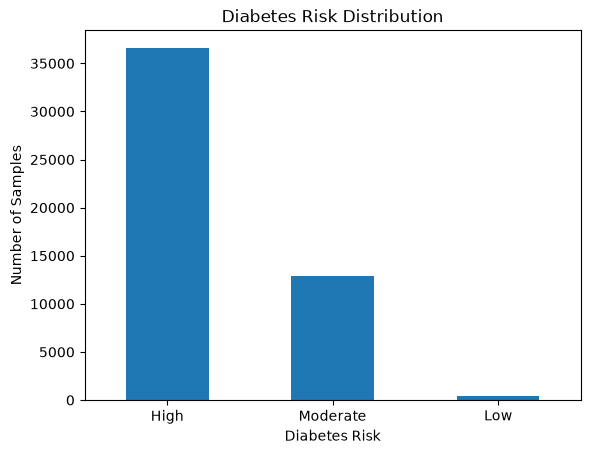

In [120]:
import matplotlib.pyplot as plt

df['Diabetes_Risk'].value_counts().plot(kind='bar')

plt.title('Diabetes Risk Distribution')
plt.xlabel('Diabetes Risk')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

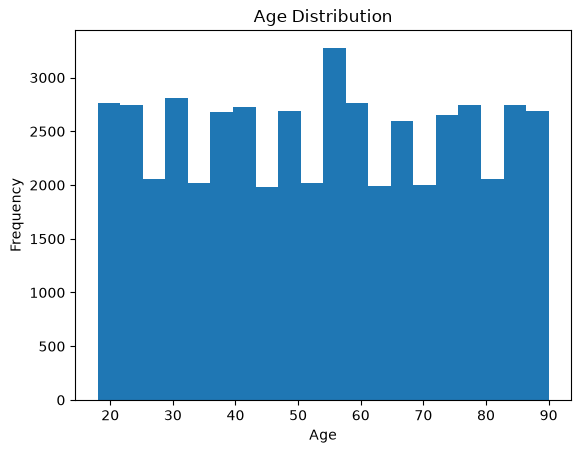

In [121]:
plt.hist(df['Age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

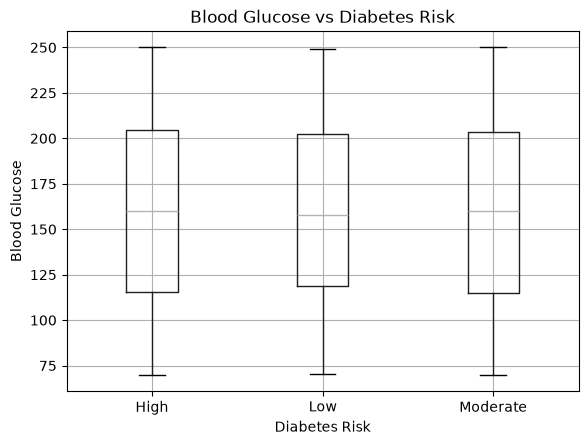

In [122]:
df.boxplot(
    column='Blood_Glucose',
    by='Diabetes_Risk'
)

plt.title('Blood Glucose vs Diabetes Risk')
plt.suptitle('')
plt.xlabel('Diabetes Risk')
plt.ylabel('Blood Glucose')
plt.show()

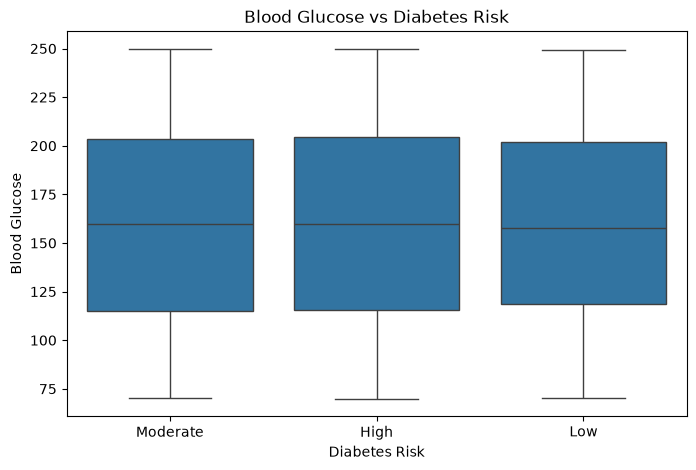

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Diabetes_Risk',
    y='Blood_Glucose'
)

plt.title('Blood Glucose vs Diabetes Risk')
plt.xlabel('Diabetes Risk')
plt.ylabel('Blood Glucose')

plt.show()

In [124]:
X = df.drop(
    ['Diabetes_Risk',
     'Diabetes_Risk_Score',
     'AI_Health_Recommendation'],
    axis=1
)

y = df['Diabetes_Risk']

In [125]:
print(X.select_dtypes(include='object').columns)

Index(['Country', 'Physical_Activity_Level', 'Diet_Quality',
       'Sugar_Intake_Level', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease'],
      dtype='str')


C:\Users\sahil akhtar\AppData\Local\Temp\ipykernel_2684\288157404.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include='object').columns)


In [126]:
categorical_cols = X.select_dtypes(include='str').columns
numeric_cols = X.select_dtypes(include='number').columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)

Categorical columns:
Index(['Country', 'Physical_Activity_Level', 'Diet_Quality',
       'Sugar_Intake_Level', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease'],
      dtype='str')

Numerical columns:
Index(['Age', 'Waist_Circumference_cm', 'Blood_Glucose', 'Fasting_Blood_Sugar',
       'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours',
       'Daily_Water_Intake_L', 'Gender_Female', 'Gender_Male', 'Gender_Other',
       'Residence_Type_Rural', 'Residence_Type_Urban', 'BMI_CATEGORY_Normal',
       'BMI_CATEGORY_Obese', 'BMI_CATEGORY_Overweight',
       'BMI_CATEGORY_Underweight', 'Doctor_Consultation_Needed_No',
       'Doctor_Consultation_Needed_Yes', 'Medication_Adherence_Average',
       'Medication_Adherence_Good', 'Medication_Adherence_

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [128]:
categorical_cols = X.select_dtypes(include='str').columns
numeric_cols = X.select_dtypes(include='number').columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numeric_cols))

Categorical: ['Country', 'Physical_Activity_Level', 'Diet_Quality', 'Sugar_Intake_Level', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease']
Numerical: ['Age', 'Waist_Circumference_cm', 'Blood_Glucose', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours', 'Daily_Water_Intake_L', 'Gender_Female', 'Gender_Male', 'Gender_Other', 'Residence_Type_Rural', 'Residence_Type_Urban', 'BMI_CATEGORY_Normal', 'BMI_CATEGORY_Obese', 'BMI_CATEGORY_Overweight', 'BMI_CATEGORY_Underweight', 'Doctor_Consultation_Needed_No', 'Doctor_Consultation_Needed_Yes', 'Medication_Adherence_Average', 'Medication_Adherence_Good', 'Medication_Adherence_Poor', 'Fatty_Liver_No', 'Fatty_Liver_Yes', 'PCOS_No', 'PCOS_Yes']


In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [131]:
X = df.drop(
    [
        'Diabetes_Risk',
        'Diabetes_Risk_Score',
        'AI_Health_Recommendation'
    ],
    axis=1
)

y = df['Diabetes_Risk']

In [132]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [133]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_processed, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [134]:
y_pred_lr = lr_model.predict(X_test_processed)

In [135]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8864

Classification Report:
              precision    recall  f1-score   support

        High       0.91      0.95      0.93      7319
         Low       0.69      0.35      0.46        94
    Moderate       0.82      0.72      0.77      2587

    accuracy                           0.89     10000
   macro avg       0.80      0.67      0.72     10000
weighted avg       0.88      0.89      0.88     10000



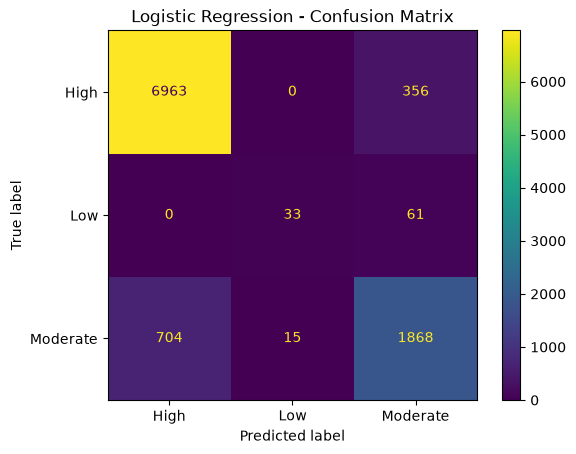

In [136]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [137]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [138]:
y_pred_rf = rf_model.predict(X_test_processed)

In [139]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8767

Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.99      0.93      7319
         Low       1.00      0.01      0.02        94
    Moderate       0.90      0.59      0.71      2587

    accuracy                           0.88     10000
   macro avg       0.92      0.53      0.55     10000
weighted avg       0.88      0.88      0.86     10000



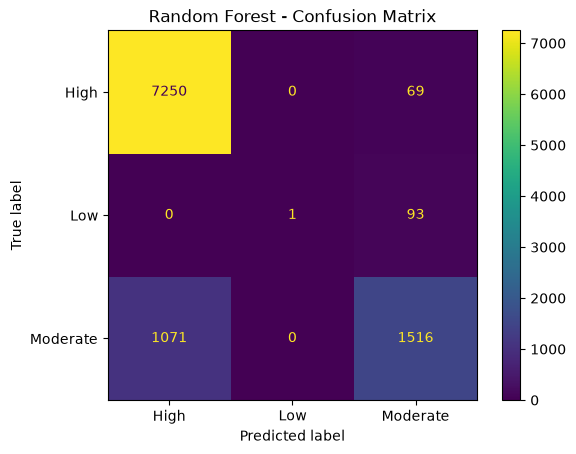

In [140]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [141]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8864
Random Forest Accuracy: 0.8767


In [142]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 83


In [143]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(15))

                                Feature  Importance
3              num__Fasting_Blood_Sugar    0.154316
25   num__Doctor_Consultation_Needed_No    0.076039
26  num__Doctor_Consultation_Needed_Yes    0.065592
0                              num__Age    0.053319
5          num__Blood_Pressure_Systolic    0.033488
7                num__Total_Cholesterol    0.031380
6         num__Blood_Pressure_Diastolic    0.026334
9                              num__LDL    0.025902
13           num__Daily_Walking_Minutes    0.025667
2                    num__Blood_Glucose    0.025353
1           num__Waist_Circumference_cm    0.025220
8                              num__HDL    0.025133
4                    num__Insulin_Level    0.024765
10                   num__Triglycerides    0.024759
14                     num__Sleep_Hours    0.024425


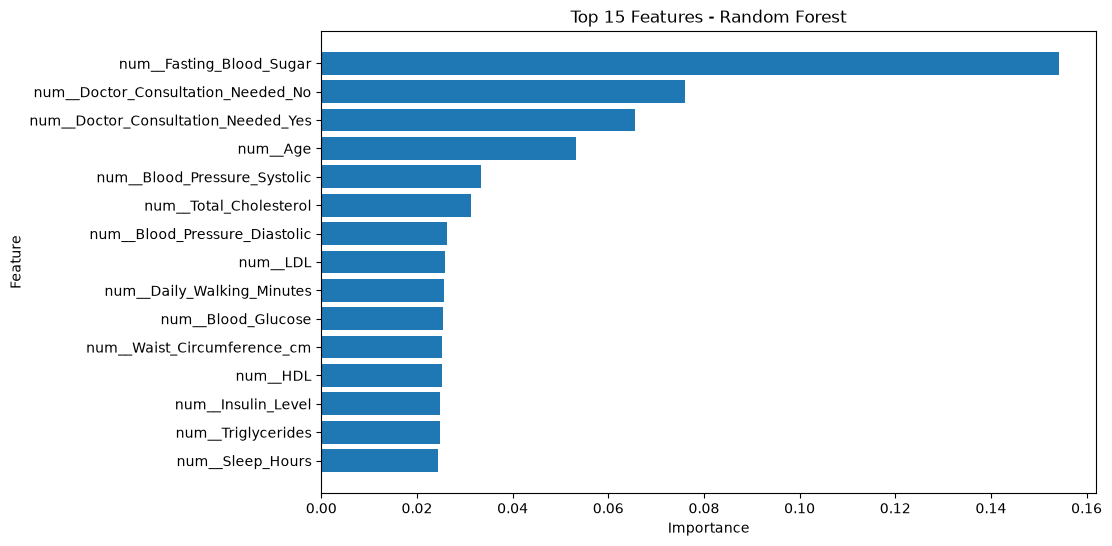

In [144]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15).sort_values(
    'Importance'
)

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 15 Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()